In [3]:

 !pip install seaborn scipy

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [9]:
file_path = '/content/data.csv'  # change if needed

# Robust loading (fix Unicode error)
try:
    df = pd.read_csv(file_path, encoding='utf-8')
except:
    try:
        df = pd.read_csv(file_path, encoding='latin1')
    except:
        df = pd.read_csv(file_path, encoding='ISO-8859-1')

print("Dataset loaded successfully ✅")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Available Columns:\n", df.columns)

Dataset loaded successfully ✅
Available Columns:
 Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')


/tmp/ipykernel_25230/1580884792.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='latin1')


In [10]:
# Try common variations automatically
possible_cols = ['no2', 'no_2', 'nitrogen dioxide']

col_found = None
for col in possible_cols:
    if col in df.columns:
        col_found = col
        break

if col_found is None:
    raise Exception("NO2 column not found. Check printed column names!")

print("Using column:", col_found)

x = df[col_found].dropna().values

print("Total samples:", len(x))

# Normalize
scaler = StandardScaler()
x = scaler.fit_transform(x.reshape(-1,1)).flatten()

Using column: no2
Total samples: 419509


a_r: 0.0 b_r: 0.6


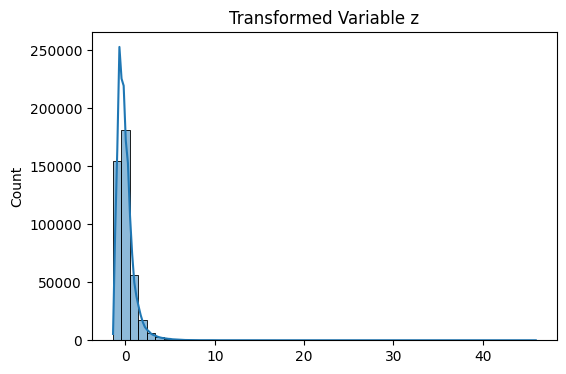

In [11]:
# 🔴 ENTER YOUR ROLL NUMBER
r = 21   # CHANGE THIS

a_r = 0.5 * (r % 7)
b_r = 0.3 * (r % 5 + 1)

print("a_r:", a_r, "b_r:", b_r)

# Transform
z = x + a_r * np.sin(b_r * x)

# Plot transformed data
plt.figure(figsize=(6,4))
sns.histplot(z, bins=50, kde=True)
plt.title("Transformed Variable z")
plt.show()

In [12]:
z = z.reshape(-1,1)
z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

In [13]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

In [14]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [15]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

lr = 0.0002
g_optimizer = optim.Adam(G.parameters(), lr=lr)
d_optimizer = optim.Adam(D.parameters(), lr=lr)

In [16]:
epochs = 3000
batch_size = 128

for epoch in range(epochs):

    idx = np.random.randint(0, z.shape[0], batch_size)
    real = z_tensor[idx]

    real_labels = torch.ones((batch_size,1)).to(device)
    fake_labels = torch.zeros((batch_size,1)).to(device)

    # Train Discriminator
    noise = torch.randn((batch_size,1)).to(device)
    fake = G(noise)

    d_real = D(real)
    d_fake = D(fake.detach())

    d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Train Generator
    noise = torch.randn((batch_size,1)).to(device)
    fake = G(noise)

    g_loss = criterion(D(fake), real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 0 | D Loss: 1.4024 | G Loss: 0.7329
Epoch 500 | D Loss: 1.4596 | G Loss: 0.7141
Epoch 1000 | D Loss: 1.3805 | G Loss: 0.7070
Epoch 1500 | D Loss: 1.3782 | G Loss: 0.6605
Epoch 2000 | D Loss: 1.3989 | G Loss: 0.7056
Epoch 2500 | D Loss: 1.3899 | G Loss: 0.6636


In [17]:
n_samples = 10000
noise = torch.randn((n_samples,1)).to(device)

generated = G(noise).detach().cpu().numpy().flatten()

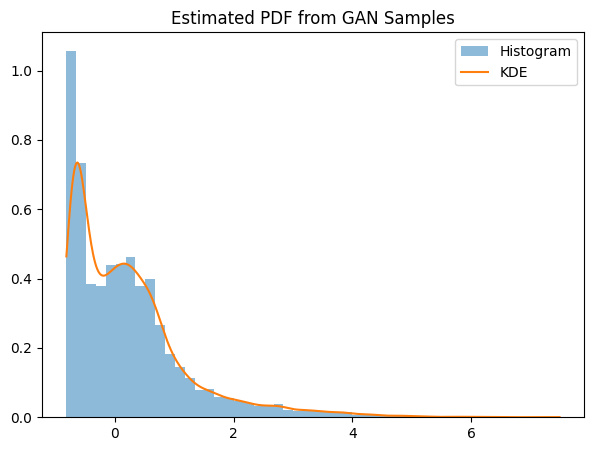

In [18]:
kde = gaussian_kde(generated)
x_vals = np.linspace(min(generated), max(generated), 500)
pdf = kde(x_vals)

plt.figure(figsize=(7,5))

plt.hist(generated, bins=50, density=True, alpha=0.5, label='Histogram')
plt.plot(x_vals, pdf, label='KDE')

plt.title("Estimated PDF from GAN Samples")
plt.legend()
plt.show()

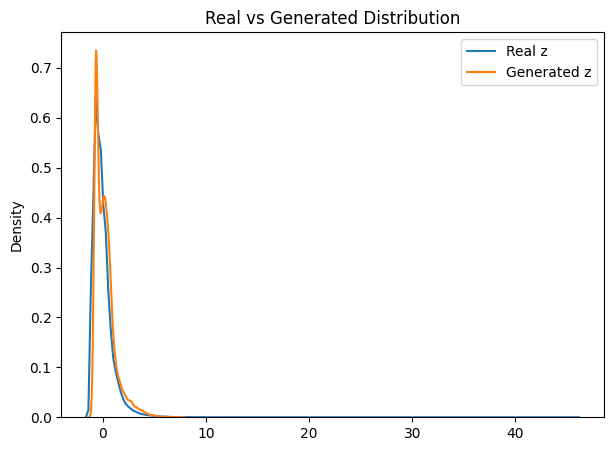

In [19]:
plt.figure(figsize=(7,5))

sns.kdeplot(z.flatten(), label='Real z')
sns.kdeplot(generated, label='Generated z')

plt.title("Real vs Generated Distribution")
plt.legend()
plt.show()